# Assignment 10: Comparing GAN and VAE Using Your Own Experimental Results

**Objective:** To compare a GAN and a VAE using the outputs from my own experiments, the DCGAN trained on Fashion-MNIST in Assignment 4 and the VAE trained on MNIST in Assignment 8, instead of relying only on theory.

## Step 1: Importing Libraries

In [1]:
import json
import base64
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

## Step 2: Reading the Saved Outputs from Assignments 4 and 8

The trained models were not saved, but the images they produced are stored inside the two notebooks. A small function is used to pull a saved picture out of a notebook. It looks for the code cell that contains a given piece of text (such as the plot title) and returns the picture that cell produced.

In [2]:
# Names of the two earlier notebooks (uploaded to Colab)
GAN_FILE = 'Assignment4_GenAI.ipynb'
VAE_FILE = 'Assignment8_GenAI.ipynb'


def get_saved_figure(notebook_file, text_in_cell, which=0):
    # 1. open the notebook file (it is a JSON file)
    with open(notebook_file) as f:
        nb = json.load(f)

    # 2. go through the code cells and find the one containing the given text
    for cell in nb['cells']:
        if cell['cell_type'] != 'code':
            continue
        code = ''.join(cell['source'])

        if text_in_cell in code:
            # 3. collect the pictures this cell produced
            pictures = [o['data']['image/png'] for o in cell['outputs']
                        if 'data' in o and 'image/png' in o['data']]
            png_text = pictures[which]
            if isinstance(png_text, list):
                png_text = ''.join(png_text)

            # 4. turn the stored text back into a picture
            return Image.open(io.BytesIO(base64.b64decode(png_text))).convert('RGB')

    raise ValueError('No code cell contains: ' + text_in_cell)

GAN figure size: (581, 592)
VAE figure size: (980, 989)


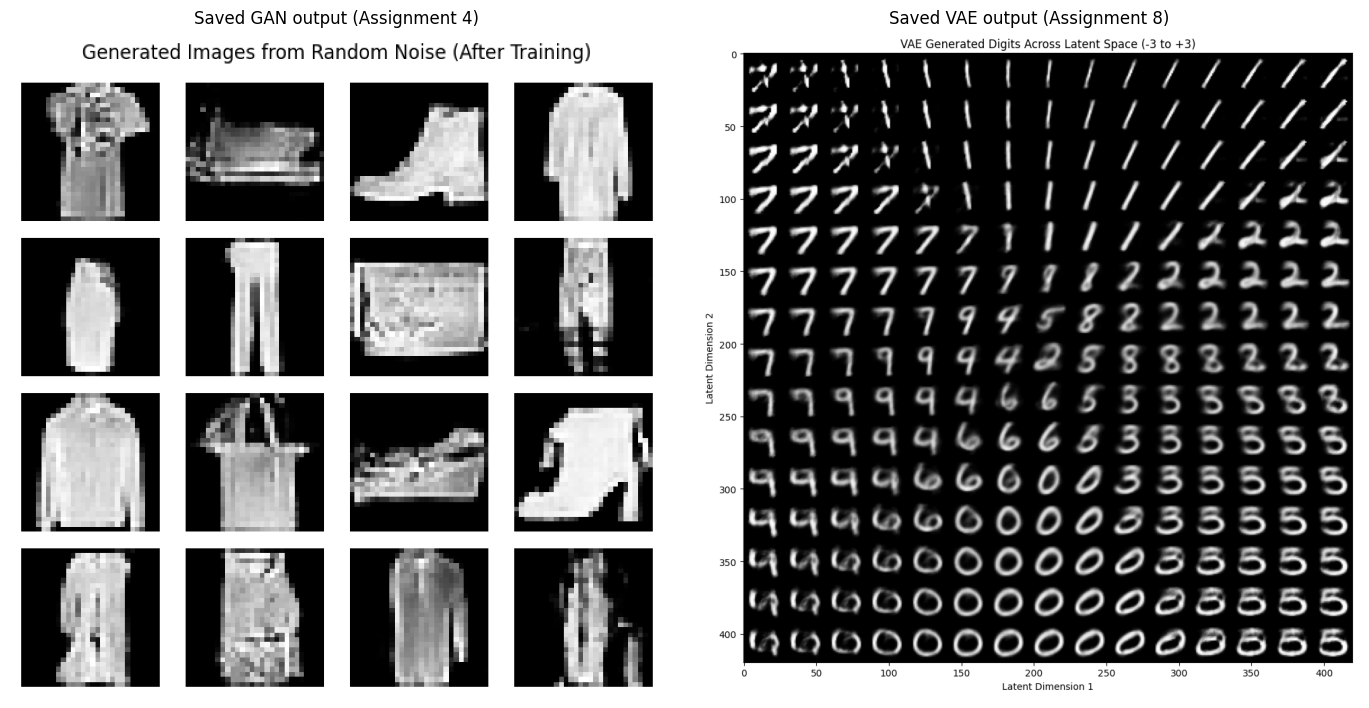

In [3]:
# GAN: the 16 images made from fresh random noise after training (Assignment 4, Step 12)
gan_figure = get_saved_figure(GAN_FILE, 'Generated Images from Random Noise')

# VAE: the grid of digits decoded across the latent space (Assignment 8, Step 13)
vae_figure = get_saved_figure(VAE_FILE, 'VAE Generated Digits Across Latent Space')

print("GAN figure size:", gan_figure.size)
print("VAE figure size:", vae_figure.size)

plt.figure(figsize=(14, 7))

plt.subplot(1, 2, 1)
plt.imshow(gan_figure)
plt.title('Saved GAN output (Assignment 4)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(vae_figure)
plt.title('Saved VAE output (Assignment 8)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Step 3: Selecting 8 GAN-Generated Images

The saved GAN picture is a 4 x 4 grid of black squares separated by white gaps. The code finds where each square is, cuts all 16 images out, and keeps the first 8 (the first two rows). The images are chosen by this fixed rule, not by how good they look.

In [4]:
def find_runs(is_filled, min_length=50):
    # goes through a list of True/False values and returns the stretches of True
    # (stretches shorter than min_length are ignored, such as thin lines of title text)
    runs = []
    start = None
    for i, value in enumerate(is_filled):
        if value and start is None:
            start = i
        if (not value) and start is not None:
            if i - start >= min_length:
                runs.append((start, i))
            start = None
    if start is not None and len(is_filled) - start >= min_length:
        runs.append((start, len(is_filled)))
    return runs


def find_grid(img):
    pixels = np.array(img)
    not_white = pixels.sum(axis=2) < 740       # white = 255+255+255 = 765, so this means "not white"
    rows = find_runs(not_white.mean(axis=1) > 0.5)   # rows of pixels that are mostly not white
    cols = find_runs(not_white.mean(axis=0) > 0.5)   # columns of pixels that are mostly not white
    return rows, cols

Row positions   : [(45, 168), (183, 306), (321, 444), (459, 582)]
Column positions: [(10, 133), (156, 279), (302, 425), (448, 571)]
Number of images cut out: 16
Size of one image       : (123, 123)


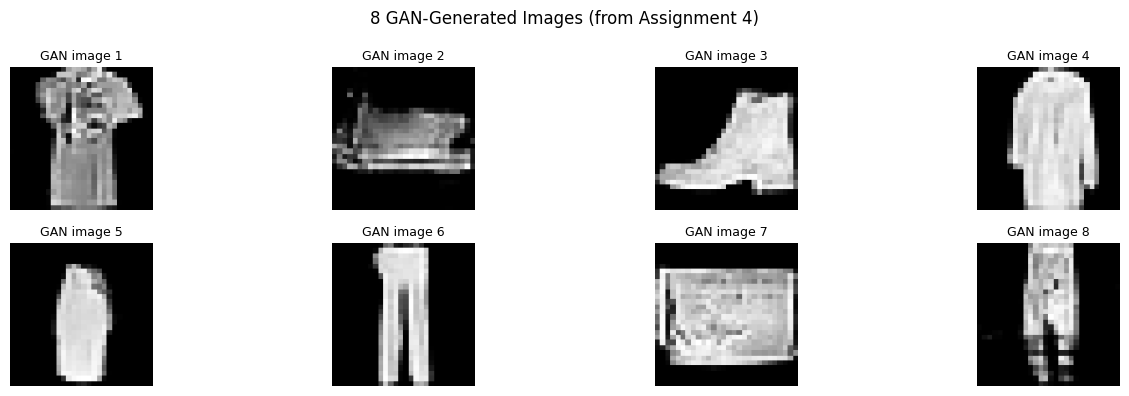

In [5]:
rows, cols = find_grid(gan_figure)
print("Row positions   :", rows)
print("Column positions:", cols)

# cut out all 16 images (crop takes: left, top, right, bottom)
gan_tiles = [gan_figure.crop((c0, r0, c1, r1)) for (r0, r1) in rows for (c0, c1) in cols]
print("Number of images cut out:", len(gan_tiles))
print("Size of one image       :", gan_tiles[0].size)

# keep the first 8 images
gan_8 = gan_tiles[:8]

plt.figure(figsize=(14, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(gan_8[i])
    plt.title(f'GAN image {i + 1}', fontsize=9)
    plt.axis('off')
plt.suptitle('8 GAN-Generated Images (from Assignment 4)')
plt.tight_layout()
plt.show()

## Step 4: Selecting 8 VAE-Generated Images

The saved VAE picture is a 15 x 15 grid of digits with no gaps. Each digit is the decoder's output for one point in the 2D latent space, from -3 to +3 in both directions (Assignment 8, Step 13). The code finds the grid, divides it into 15 x 15 equal squares, and selects 8 squares at evenly spaced positions (rows 4 and 12, and columns 2, 6, 10 and 14, counting from 1). The positions follow a fixed spacing, not how good the digits look.

In [6]:
rows, cols = find_grid(vae_figure)
print("Row positions   :", rows)
print("Column positions:", cols)

# the whole grid is one big block, so we get its edges and divide it into 15 x 15 squares
top, bottom = rows[0]
left, right = cols[0]
n = 15
tile_width  = (right - left) / n
tile_height = (bottom - top) / n
print(f"Size of one image: about {tile_width:.1f} x {tile_height:.1f} pixels")


def get_vae_tile(r, c):
    # cuts out the square in row r and column c (counting from 0)
    return vae_figure.crop((round(left + c * tile_width),
                            round(top + r * tile_height),
                            round(left + (c + 1) * tile_width),
                            round(top + (r + 1) * tile_height)))

Row positions   : [(30, 938)]
Column positions: [(65, 972)]
Size of one image: about 60.5 x 60.5 pixels


Number of images selected: 8


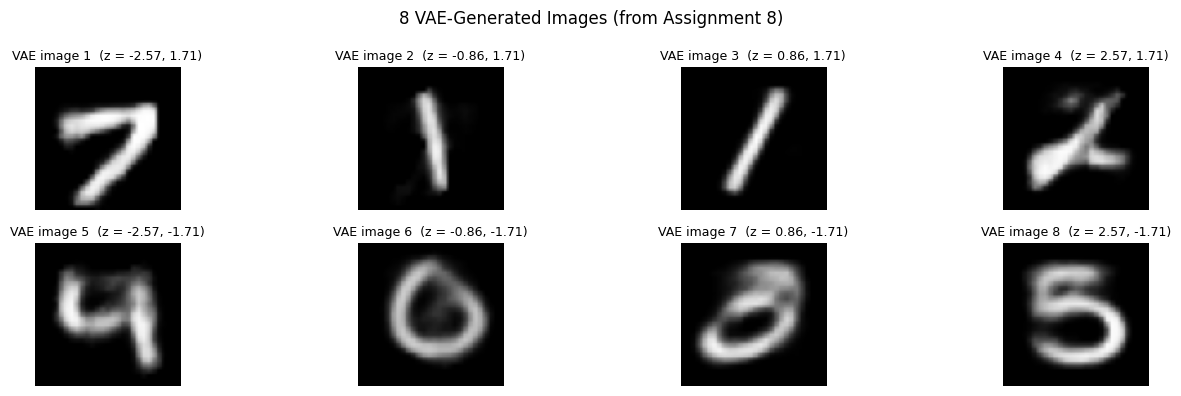

In [7]:
chosen_rows = [3, 11]          # rows 4 and 12 (counting from 1)
chosen_cols = [1, 5, 9, 13]    # columns 2, 6, 10 and 14 (counting from 1)

vae_8 = []
vae_coords = []
for r in chosen_rows:
    for c in chosen_cols:
        vae_8.append(get_vae_tile(r, c))
        # latent point of this square: the grid ran from -3 to +3 in 15 steps (Assignment 8, Step 13)
        x = -3 + c * 6 / (n - 1)
        y = 3 - r * 6 / (n - 1)          # the top row of the picture is y = +3
        vae_coords.append((x, y))

print("Number of images selected:", len(vae_8))

plt.figure(figsize=(14, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(vae_8[i])
    plt.title(f'VAE image {i + 1}  (z = {vae_coords[i][0]:.2f}, {vae_coords[i][1]:.2f})', fontsize=9)
    plt.axis('off')
plt.suptitle('8 VAE-Generated Images (from Assignment 8)')
plt.tight_layout()
plt.show()

## Step 5: GAN and VAE Generated Images Side by Side

The 8 GAN images (top row) and the 8 VAE images (bottom row), all taken from the outputs of Assignments 4 and 8. The GAN was trained on Fashion-MNIST (clothing) and the VAE on MNIST (handwritten digits), so the two sets show different kinds of images.

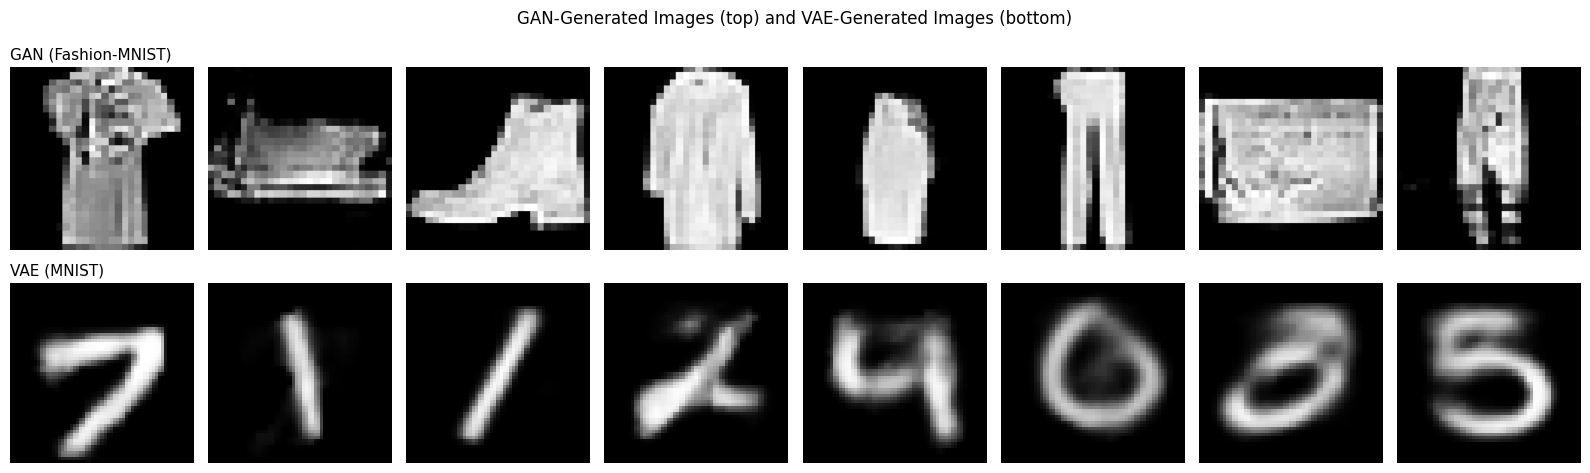

In [8]:
plt.figure(figsize=(16, 5))

for i in range(8):
    # top row: GAN images
    plt.subplot(2, 8, i + 1)
    plt.imshow(gan_8[i])
    plt.axis('off')
    if i == 0:
        plt.title('GAN (Fashion-MNIST)', loc='left', fontsize=11)

    # bottom row: VAE images
    plt.subplot(2, 8, i + 9)
    plt.imshow(vae_8[i])
    plt.axis('off')
    if i == 0:
        plt.title('VAE (MNIST)', loc='left', fontsize=11)

plt.suptitle('GAN-Generated Images (top) and VAE-Generated Images (bottom)')
plt.tight_layout()
plt.show()

## Step 6: Supporting Outputs from Assignments 4 and 8

These outputs are used as evidence for the comparison table and the final verdict:
- The training loss plots of both models (training stability).
- The VAE's original vs reconstructed images (sharpness and anomaly detection).
- The VAE's images from extreme latent points and from a point outside the latent space (anomaly detection).

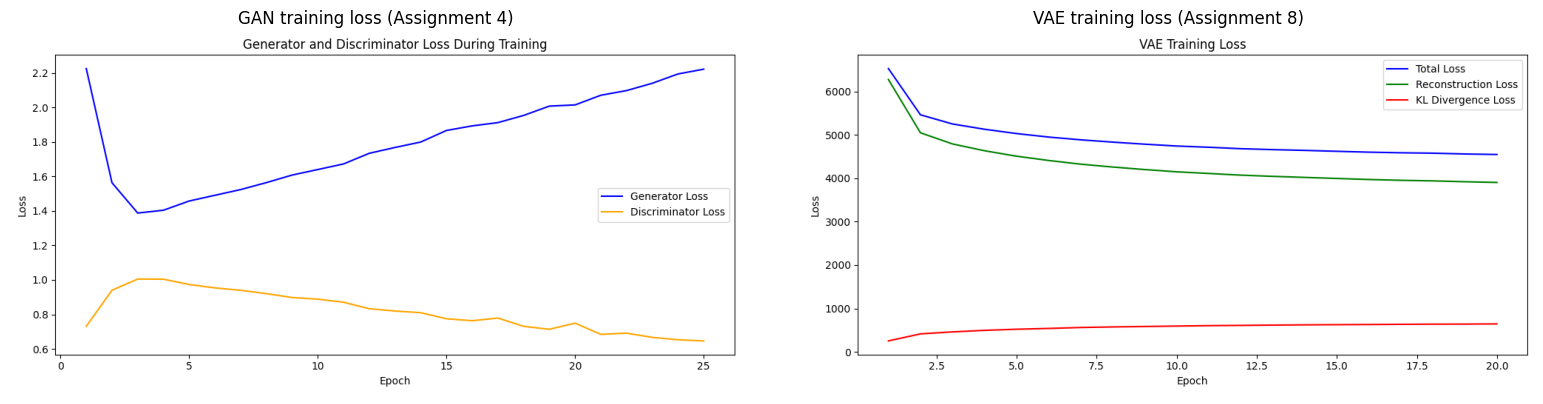

In [9]:
# Pull the five saved pictures out of the two notebooks
gan_loss_plot = get_saved_figure(GAN_FILE, 'Generator and Discriminator Loss During Training')
vae_loss_plot = get_saved_figure(VAE_FILE, 'VAE Training Loss')
vae_recon = get_saved_figure(VAE_FILE, 'Original vs Reconstructed Images (VAE)')
vae_extreme = get_saved_figure(VAE_FILE, 'Generated Images from Extreme Latent Points')
vae_outside = get_saved_figure(VAE_FILE, 'Generated Image from Outside Latent Space')

# 1. Training loss of both models (training stability)
plt.figure(figsize=(16, 4))

plt.subplot(1, 2, 1)
plt.imshow(gan_loss_plot)
plt.title('GAN training loss (Assignment 4)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(vae_loss_plot)
plt.title('VAE training loss (Assignment 8)')
plt.axis('off')

plt.tight_layout()
plt.show()

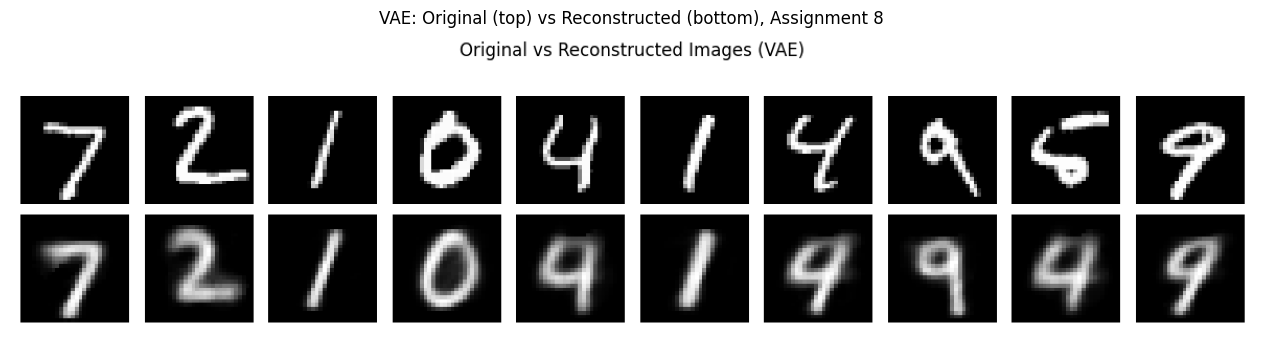

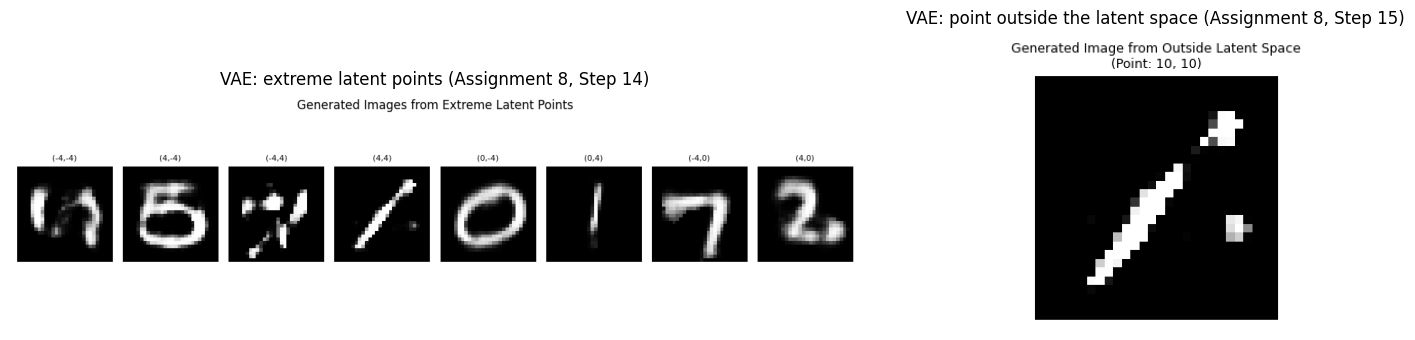

In [10]:
# 2. VAE: original vs reconstructed images (Assignment 8, Step 11)
plt.figure(figsize=(14, 3.5))
plt.imshow(vae_recon)
plt.title('VAE: Original (top) vs Reconstructed (bottom), Assignment 8')
plt.axis('off')
plt.tight_layout()
plt.show()

# 3. VAE: images from extreme latent points and from a point outside the latent space
plt.figure(figsize=(16, 3.5))

plt.subplot(1, 2, 1)
plt.imshow(vae_extreme)
plt.title('VAE: extreme latent points (Assignment 8, Step 14)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(vae_outside)
plt.title('VAE: point outside the latent space (Assignment 8, Step 15)')
plt.axis('off')

plt.tight_layout()
plt.show()

## Step 7: Comparison Table

The comparison is based on the 8 images from each model and on the loss plots and other outputs from Assignments 4 and 8. The GAN was trained on Fashion-MNIST (clothing) and the VAE on MNIST (digits), so the two are not tested on the same data.

| Criteria | GAN (Assignment 4, Fashion-MNIST) | VAE (Assignment 8, MNIST) |
|---|---|---|
| Image sharpness | Edges are fairly sharp and some fabric detail is visible (T-shirt, boot, coat). | Soft and blurry. All 8 images have fuzzy edges, and the reconstructions in Step 11 are blurry too. |
| Diversity | The 8 images show several different items (T-shirt, ankle boot, coat or dress, trousers). | The full grid in Step 13 contains all ten digits. But it is a sweep over latent points, not random samples, and neighbouring points often give the same digit (two of my 8 images are 1s). |
| Realism | Four of the 8 images are clear items (T-shirt, boot, coat, trousers). The other four are unclear: a smudgy shape, a blob, a flat rectangle and a broken pair of trousers. | All 8 can be read as digits, but they look like blurred handwriting. Image 4 has smudge marks and image 7 is between an 8 and a 0. |
| Training stability | Unsteady. In the Assignment 4 training log, the generator loss fell from 2.23 to 1.39 in the first 3 epochs, then rose steadily to 2.22 by epoch 25. The discriminator loss rose to 1.00 and then fell to 0.65. The two losses never settled. | Steady. In the Assignment 8 training log, the total loss fell smoothly from 6530 to 4550 in 20 epochs, with no jumps. The KL loss rose slowly from 252 to 645 and levelled off. |
| Ease of controlling the output | Hard. The generator takes a random noise vector of 100 values, and in Assignment 4 I had no way to choose what it made (a boot or trousers). | Easier. The latent space has only 2 values and each image comes from a known point (the z values in the titles). Moving across the grid in Step 13 changed the digit gradually, so the output can be steered by choosing the point. |
| Risk of mode collapse | Present. My GAN did not collapse, because the images showed different items. But the losses never settled and about half of the images were flawed, so it was not fully stable. | Low. The VAE is trained to rebuild every training image, and the grid contains all ten digits. But the 2-value latent space merges similar digits: in Step 11 a 4 became a 9 twice, and the 5 came out looking like a 4 or 9. |
| Typical applications (general knowledge, not tested in these experiments) | Generating realistic images, creating extra training data, image-to-image translation. | Anomaly detection, data compression, generating variations of an image, exploring the latent space. |

**Things to keep in mind:** the two models used different datasets. The VAE is a small network with only 2 latent values, which probably adds to its blur. Each model was trained once, and only 8 images from each were compared. So this table describes my experiments and is not a general rule.

## Final Decision

**1. Which model would I prefer for generating synthetic training data?**

The GAN. In my outputs, the GAN images had sharper edges and more detail than the soft VAE images, and the 8 GAN images showed several different items. Training data should look like real data, and blurry images could teach a model to expect blur (this is my reasoning and I did not test it). There are limits. Only about half of my 8 GAN images were clear, so generated images would need to be checked before use. My GAN also gave no way to choose which item it made, so I could not control the balance between classes. If control matters more than sharpness, the VAE would be the better choice.

**2. Which model would I prefer for anomaly detection?**

The VAE. It has both an encoder and a decoder, so it can take a real image, compress it and rebuild it. An image that does not look like the training data should be rebuilt badly, and that error can be used as an anomaly score. My Assignment 8 outputs support this indirectly. The decoder gave clear digits inside the region it learned, but broken shapes at extreme points such as (-4, 4) and a meaningless streak at (10, 10), where the mean pixel value was only 0.0735. I did not run an actual anomaly detection test, so this is an inference from the outputs. The GAN from Assignment 4 only takes random noise as input and has no encoder, so it cannot rebuild a new image to compare with the original.

**3. Why?**

The GAN is better at producing sharp, realistic-looking images, but its training was unsteady and I could not control what it generated. The VAE trained steadily, is easier to control and can rebuild an input image, but its images are blurrier. So the better model depends on the job: sharp images for synthetic data, and a model that can rebuild an input for anomaly detection.

**Limitations:** the models were trained on different datasets, the VAE is small, each model was trained once, and only 8 images from each were compared.